In [1]:
import numpy as np

class RegresionLogPesada :
    def __init__(self, tau, kernel="gaussiano", d=None) -> None:
        """
        Inicializa el modelo de regresión logística local ponderada.
        :param tau: Parámetro de ancho para el kernel.
        :param kernel: Tipo de kernel a utilizar ("gaussiano" o "tricubo").
        :param d: Parámetro de distancia para el kernel tricubo (requerido si
                        se selecciona el kernel tricubo).
        :authors: Brian Fernandez | Tomas Borstner | Brenda Ordoñez | Joaquin Pereyra | Lucas Colossimo | Tomas Macrade
        :date: 13/06/2026
        """

        self.tau = tau
        self.kernel = kernel
        self.d = d

    def _calcular_pesos(self, X, x_objetivo) -> np.ndarray:
        """Calcula los pesos para cada punto en X basados en su distancia a x_objetivo utilizando el kernel seleccionado.
        :param X: Matriz de datos de entrada.
        :param x_objetivo: Punto objetivo para el cual calcular los pesos.
        :return: Vector de pesos.
        :authors: Brian Fernandez | Tomas Borstner | Brenda Ordoñez | Joaquin Pereyra | Lucas Colossimo | Tomas Macrade
        :date: 13/06/2026
        """
        dist = np.linalg.norm(X - x_objetivo, axis=1)

        if self.kernel == "gaussiano":
            w = np.exp(-(dist ** 2) / (2 * self.tau ** 2))
        elif self.kernel == "tricubo":
            if self.d is None:
                raise ValueError("Debe especificar d para kernel tricubo.")
            u = dist / self.d
            w = np.zeros_like(dist)
            mask = u < 1
            w[mask] = (1 - u[mask] ** 3) ** 3
        else:
            raise ValueError("Kernel no reconocido.")

        return w

    def _agregar_intercepto_X(self, X) -> np.ndarray:
        """
        Agrega una columna de unos a la matriz de datos para el término de intercepto.
        :param X: Matriz de datos de entrada.
        :return: Matriz de datos con columna de unos agregada.
        :authors: Brian Fernandez | Tomas Borstner | Brenda Ordoñez | Joaquin Pereyra | Lucas Colossimo | Tomas Macrade
        :date: 13/06/2026
        """
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return np.column_stack([np.ones(X.shape[0]), X])

    def _agregar_intercepto_punto(self, x) -> np.ndarray:
        """
        Agrega un término de intercepto a un punto objetivo.
        :param x: Punto objetivo (vector).
        :return: Punto objetivo con término de intercepto agregado.
        :authors: Brian Fernandez | Tomas Borstner | Brenda Ordoñez | Joaquin Pereyra | Lucas Colossimo | Tomas Macrade
        :date: 13/06/2026
        """
        x = np.asarray(x).ravel()
        return np.concatenate([[1.0], x])

    def _entrenar(self, X, y, x_objetivo, max_iter=80, tol=1e-6, lr=0.05) -> np.ndarray:
        """
        Calcula los pesos para cada punto en X basados en su distancia a x_objetivo y ajusta un modelo de regresión logística local ponderada.
        :param X: Matriz de datos de entrada.
        :param y: Vector de etiquetas.
        :param x_objetivo: Punto objetivo para el cual calcular los pesos.
        :param max_iter: Número máximo de iteraciones para el descenso de gradiente.
        :param tol: Tolerancia para la convergencia.
        :param lr: Tasa de aprendizaje para el descenso de gradiente.
        :return: Vector de parámetros ajustados.
        :authors: Brian Fernandez | Tomas Borstner | Brenda Ordoñez | Joaquin Pereyra | Lucas Colossimo | Tomas Macrade
        :date: 13/06/2026
        """
        w = self._calcular_pesos(X, x_objetivo)
        theta = np.zeros(X.shape[1])

        for _ in range(max_iter):
            z = X @ theta
            p = 1 / (1 + np.exp(-z))
            grad = X.T @ (w * (p - y))

            theta_new = theta + lr * grad

            if np.linalg.norm(theta_new - theta) < tol:
                theta = theta_new
                break
            theta = theta_new

        return theta

    def predecir_proba(self, X, y, x_objetivo) -> float:
        """
        Realiza una predicción de probabilidad para un punto objetivo.
        :param X: Matriz de datos de entrada.
        :param y: Vector de etiquetas.
        :param x_objetivo: Punto objetivo para el cual predecir.
        :return: Probabilidad de pertenecer a la clase positiva.
        :authors: Brian Fernandez | Tomas Borstner | Brenda Ordoñez | Joaquin Pereyra | Lucas Colossimo | Tomas Macrade
        :date: 13/06/2026
        """
        X = self._agregar_intercepto_X(X)
        x_objetivo = self._agregar_intercepto_punto(x_objetivo)
        params = self._entrenar(X, y, x_objetivo)
        return 1 / (1 + np.exp(-(x_objetivo @ params)))

    def predecir_clase(self, X, y, x_objetivo, umbral=0.5) -> int:
        """
        Realiza una predicción de clase para un punto objetivo basado en la probabilidad predicha.
        :param X: Matriz de datos de entrada.
        :param y: Vector de etiquetas.
        :param x_objetivo: Punto objetivo para el cual predecir.
        :param umbral: Umbral para clasificar como clase positiva.
        :return: Clase predicha (0 o 1).
        :authors: Brian Fernandez | Tomas Borstner | Brenda Ordoñez | Joaquin Pere
                    | Lucas Colossimo | Tomas Macrade
        :date: 13/06/2026
        """
        return int(self.predecir_proba(X, y, x_objetivo) > umbral)

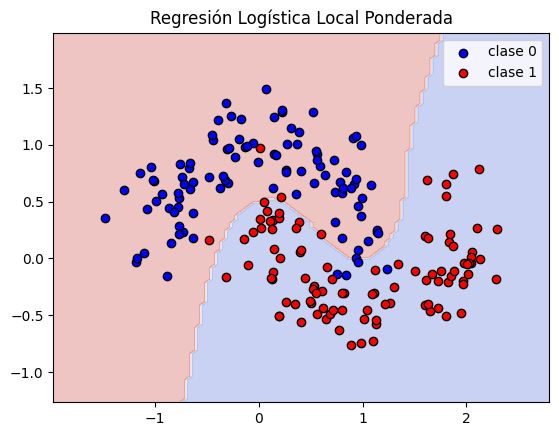

In [2]:
import matplotlib.pyplot as plt

# Datos sintéticos: dos lunas entrelazadas
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

# Instanciar modelo con kernel gaussiano y tau adecuado
modelo = RegresionLogPesada(tau=0.3, kernel="gaussiano")

# Evaluar en una malla para pintar la frontera
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 100),
                     np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 100))
grid = np.c_[xx.ravel(), yy.ravel()]

# Predecir cada punto de la malla (puede ser un poco lento, pero funciona)
Z = np.array([modelo.predecir_clase(X, y, punto) for punto in grid])
Z = Z.reshape(xx.shape)

# Graficar
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[y==0,0], X[y==0,1], c='blue', label='clase 0', edgecolors='k')
plt.scatter(X[y==1,0], X[y==1,1], c='red', label='clase 1', edgecolors='k')
plt.legend()
plt.title("Regresión Logística Local Ponderada")
plt.show()

/tmp/ipykernel_11646/298565804.py:110: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-(x_objetivo @ params)))
/tmp/ipykernel_11646/298565804.py:85: RuntimeWarning: overflow encountered in exp
  p = 1 / (1 + np.exp(-z))


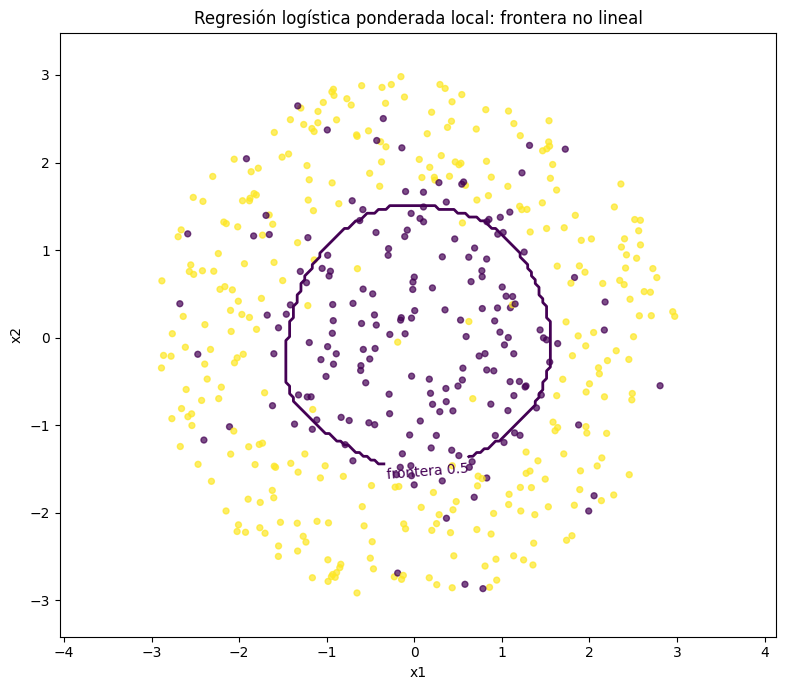

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)
n = 500

r = np.sqrt(np.random.rand(n)) * 3.0
theta = 2 * np.pi * np.random.rand(n)

X = np.column_stack([r * np.cos(theta), r * np.sin(theta)])
radio = np.linalg.norm(X, axis=1)

# Clase 1 afuera del radio 1.7, clase 0 adentro
y = (radio > 1.7).astype(int)

# Un poco de ruido en etiquetas
flip = np.random.rand(n) < 0.08
y[flip] = 1 - y[flip]

# -----------------------------
# Modelo
# -----------------------------
modelo = RegresionLogPesada(tau=0.55, kernel="gaussiano")

# -----------------------------
# Malla para ver frontera de decisión
# -----------------------------
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 160),
    np.linspace(x2_min, x2_max, 160),
)

grid = np.c_[xx1.ravel(), xx2.ravel()]

# Probabilidad local para cada punto de la grilla
probas = np.array([modelo.predecir_proba(X, y, p) for p in grid]).reshape(xx1.shape)

# -----------------------------
# Gráfico
# -----------------------------
plt.figure(figsize=(8, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, s=18, alpha=0.7)
cont = plt.contour(xx1, xx2, probas, levels=[0.5], linewidths=2)
plt.clabel(cont, fmt={0.5: "frontera 0.5"}, inline=True)

plt.title("Regresión logística ponderada local: frontera no lineal")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.tight_layout()
plt.show()
